# Medical Image Processing and Segmentation

**Date:** March 2026  


---

Pneumonia is the leading infectious cause of mortality in children under five worldwide, responsible for 14% of deaths in that age group (UNICEF, 2023). Diagnosis relies heavily on chest X-rays, but interpreting these images requires specialized personnel that is not always available, especially in primary care settings and in countries with limited resources.

In this work we apply classical processing and segmentation techniques to the **PneumoniaMNIST** dataset (Yang et al., 2023), a subset of MedMNIST v2 containing 5,856 pediatric chest X-rays from the Guangzhou Women and Children's Medical Center. The images correspond to children aged 1 to 5 years, were classified by three expert physicians with senior radiologist validation (Kermany et al., 2018), and are resized to 28x28 pixels in grayscale.

The objective is twofold: to apply classical image processing and segmentation techniques to real medical data, and to honestly evaluate where these methods work, where they fail, and what implications each technical decision has when the images we process have real clinical origin.

## 0. Environment Setup and Dataset Loading

We import the necessary libraries for image processing (OpenCV, NumPy, Matplotlib, PIL) and load the PneumoniaMNIST dataset through the MedMNIST API. The random seed (`np.random.seed(42)`) ensures that selected samples are reproducible across executions.

The dataset may return image arrays with shape `(N, 28, 28)` or `(N, 28, 28, 1)` depending on the library version. We check the dimension and remove the redundant channel if present, to always work with 2D matrices.

PneumoniaMNIST is distributed split into three sets: training (train), validation (val), and test. For this work we load the training set, which contains 4,708 images. The complete dataset totals 5,856 images (Yang et al., 2023).

In [1]:
%pip install medmnist opencv-python numpy matplotlib Pillow scipy -q

import os
import tempfile
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from medmnist import PneumoniaMNIST
from scipy.ndimage import sobel as sobel_scipy

# Fix random seed for reproducible sampling across runs
np.random.seed(42)

# Load the PneumoniaMNIST training split (28x28 grayscale chest X-rays)
train_data = PneumoniaMNIST(split='train', download=True)
# Extract image array (N, 28, 28, 1) and label array (N, 1)
imgs = train_data.imgs
# Flatten labels from shape (N, 1) to (N,) for easier indexing
labels = train_data.labels.flatten()

# Remove the singleton channel dimension: (N, 28, 28, 1) -> (N, 28, 28)
if imgs.ndim == 4:
    imgs = imgs.squeeze(axis=-1)

print(f'Dataset loaded: {imgs.shape[0]} images of {imgs.shape[1]}x{imgs.shape[2]} pixels')
print(f'Classes: 0 = Normal, 1 = Pneumonia')
print(f'Distribution: {np.sum(labels == 1)} pneumonia ({np.sum(labels == 1)/len(labels)*100:.1f}%) / '
      f'{np.sum(labels == 0)} normal ({np.sum(labels == 0)/len(labels)*100:.1f}%)')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 3.8 MB/s eta 0:00:00


100%|██████████| 4.17M/4.17M [00:01<00:00, 4.17MB/s]

Dataset loaded: 4708 images of 28x28 pixels
Classes: 0 = Normal, 1 = Pneumonia
Distribution: 3494 pneumonia (74.2%) / 1214 normal (25.8%)


The dataset distribution shows an imbalance towards the pneumonia class (74.2% vs 25.8%). This imbalance has a clinical explanation that is developed further below.

---
## 1. Image Format Selection

The main digital image formats differ fundamentally in how they compress information: with or without loss.

| Format | Compression | Data loss | For medical imaging |
|:-------|:------------|:----------|:-------------------|
| **JPEG** | Lossy | Yes: removes information and generates visible artifacts | Not recommended |
| **PNG** | Lossless | No: the reconstructed image is identical to the original | Adequate |
| **TIFF** | Lossless | No: preserves the full dynamic range | Optimal |

### Choice: TIFF as optimal format, PNG as a valid alternative

Both PNG and TIFF use lossless compression, meaning the image read back is bit-for-bit identical to the one saved. The advantage of TIFF over PNG is that it supports greater bit depth (up to 32 bits per channel versus 16 for PNG), allowing more gray levels to be preserved. In high-resolution radiological imaging this is relevant because digital detectors capture more information than fits in 8 bits. For detailed processing, TIFF is the optimal choice.

PNG is a perfectly valid alternative when the image is already in 8 bits. In this work, PneumoniaMNIST is distributed in NPZ format with uint8 images (256 gray levels), so PNG preserves all available information without loss.

**JPEG is not acceptable** for medical imaging. When compressing, it removes information that cannot be recovered and generates artifacts that did not exist in the original image. In a chest X-ray, a compression artifact can simulate a pulmonary opacity that does not exist, or mask a real subtle opacity. Both situations have direct diagnostic consequences. For this reason, the DICOM standard, the format used in hospital imaging systems, employs lossless compression by default.

Below we demonstrate the real effect of JPEG compression on a dataset X-ray. We save the same image in TIFF and PNG (both lossless) and in JPEG at quality 75, and compute the absolute pixel-by-pixel difference. The heatmap shows where JPEG introduced error.

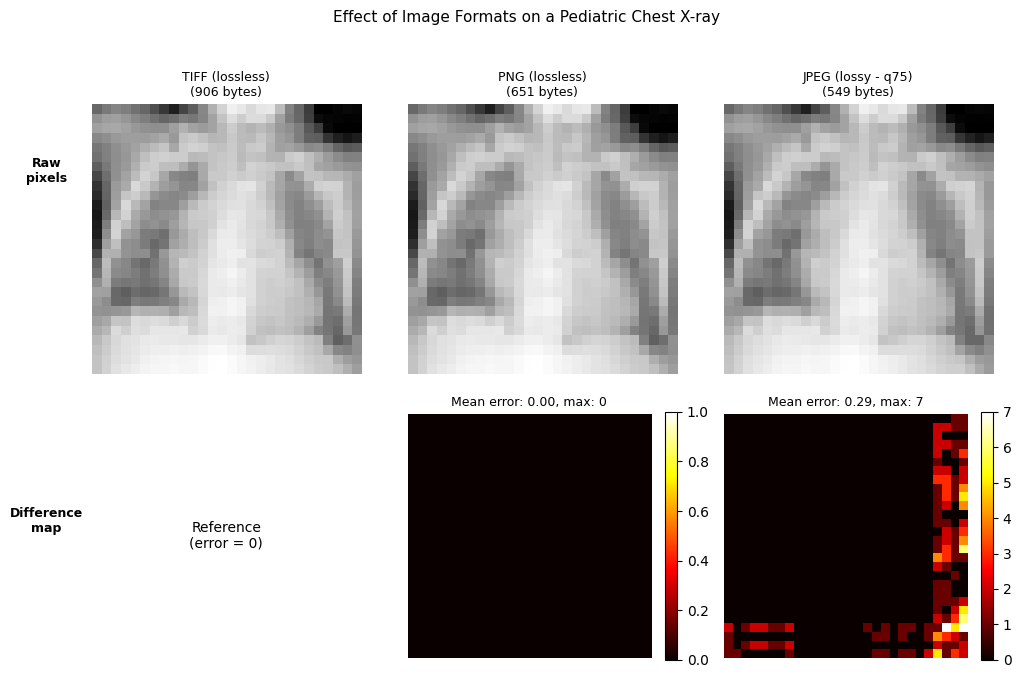

In [2]:
def demonstrate_format_artifacts(img):
    """Compares formats: raw pixels and difference heatmaps."""
    # Convert numpy array to PIL Image for saving in different formats
    img_pil = Image.fromarray(img)

    # Create a temporary directory that auto-deletes after use
    with tempfile.TemporaryDirectory() as tmpdir:
        # Define output paths for each format
        paths = {
            'TIFF (lossless)': os.path.join(tmpdir, 'img.tiff'),
            'PNG (lossless)': os.path.join(tmpdir, 'img.png'),
            'JPEG (lossy - q75)': os.path.join(tmpdir, 'img_q75.jpg'),
        }

        # Save the same image in three different formats
        img_pil.save(paths['TIFF (lossless)'], format='TIFF')
        img_pil.save(paths['PNG (lossless)'])
        # JPEG quality=75: default compression level, introduces lossy artifacts
        img_pil.save(paths['JPEG (lossy - q75)'], quality=75)

        # Re-read each saved file back into numpy arrays
        images = {k: np.array(Image.open(v)) for k, v in paths.items()}
        # Measure file size in bytes for each format
        sizes = {k: os.path.getsize(v) for k, v in paths.items()}

    # Use PNG as the lossless reference for computing pixel differences
    ref = images['PNG (lossless)'].astype(float)

    fig, axes = plt.subplots(2, 3, figsize=(10, 7))

    # Row 1: display raw pixels of each format
    fig.text(0.02, 0.75, 'Raw\npixels', fontsize=9, fontweight='bold', va='center', ha='center')
    for ax, (title, img_fmt) in zip(axes[0], images.items()):
        ax.imshow(img_fmt, cmap='gray')
        ax.set_title(f'{title}\n({sizes[title]} bytes)', fontsize=9)
        ax.axis('off')

    # Row 2: heatmaps showing absolute pixel difference vs PNG reference
    fig.text(0.02, 0.25, 'Difference\nmap', fontsize=9, fontweight='bold', va='center', ha='center')
    # PNG vs itself = zero error, show placeholder text
    axes[1][0].text(0.5, 0.5, 'Reference\n(error = 0)', ha='center', va='center', fontsize=10)
    axes[1][0].axis('off')

    for ax, key in zip(axes[1][1:], ['TIFF (lossless)', 'JPEG (lossy - q75)']):
        # Compute absolute pixel-wise difference against the PNG reference
        diff = np.abs(ref - images[key].astype(float))
        # Display difference heatmap — 'hot' colormap highlights error regions
        im = ax.imshow(diff, cmap='hot', vmin=0, vmax=max(diff.max(), 1))
        ax.set_title(f'Mean error: {diff.mean():.2f}, max: {diff.max():.0f}', fontsize=9)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046)

    plt.suptitle('Effect of Image Formats on a Pediatric Chest X-ray', fontsize=11)
    plt.tight_layout(rect=[0.05, 0, 1, 0.96])
    plt.show()

# Run the comparison on the first image of the dataset
demonstrate_format_artifacts(imgs[0])

The first row shows the raw pixels of each format, where both PNG and TIFF maintain exact pixel fidelity. The second row quantifies the error through difference heatmaps: PNG displays a completely black map (error = 0), confirming that its lossless compression preserves every pixel identically to the TIFF reference. In contrast, JPEG quality 75 introduces measurable error. Although this overall error may seem low, any alteration in pixel intensity is significant in medical imaging, where subtle changes can correspond to critical clinical findings.

---
## 2. Dataset Exploration

We begin with a detailed exploration of the dataset that includes:

1. A random sample of 10 images that **respects the real dataset distribution** (74.2/25.8% of the training set), so that the sample is representative.
2. A balanced selection of 5 images per class, arranged in separate rows, to facilitate visual comparison between normal and pathological X-rays.
3. The class distribution of the complete dataset and intensity statistics per class.

### On the dataset imbalance

The training set distribution is 74.2% pneumonia and 25.8% normal. This imbalance is not a sampling defect or selection bias: it reflects the real prevalence of a symptomatic pediatric cohort. Children who are referred for a chest X-ray already present with clinical suspicion (fever, cough, respiratory distress), so the proportion of positive cases is naturally high in that population. In epidemiology this is called verification bias, and it is inherent to any dataset built from images requested by clinical indication.

### 2.1 Random sample of 10 images

We randomly select 10 images from the training set. Since 74.2% of the dataset corresponds to pneumonia, it is expected that most of the sample will belong to that class.

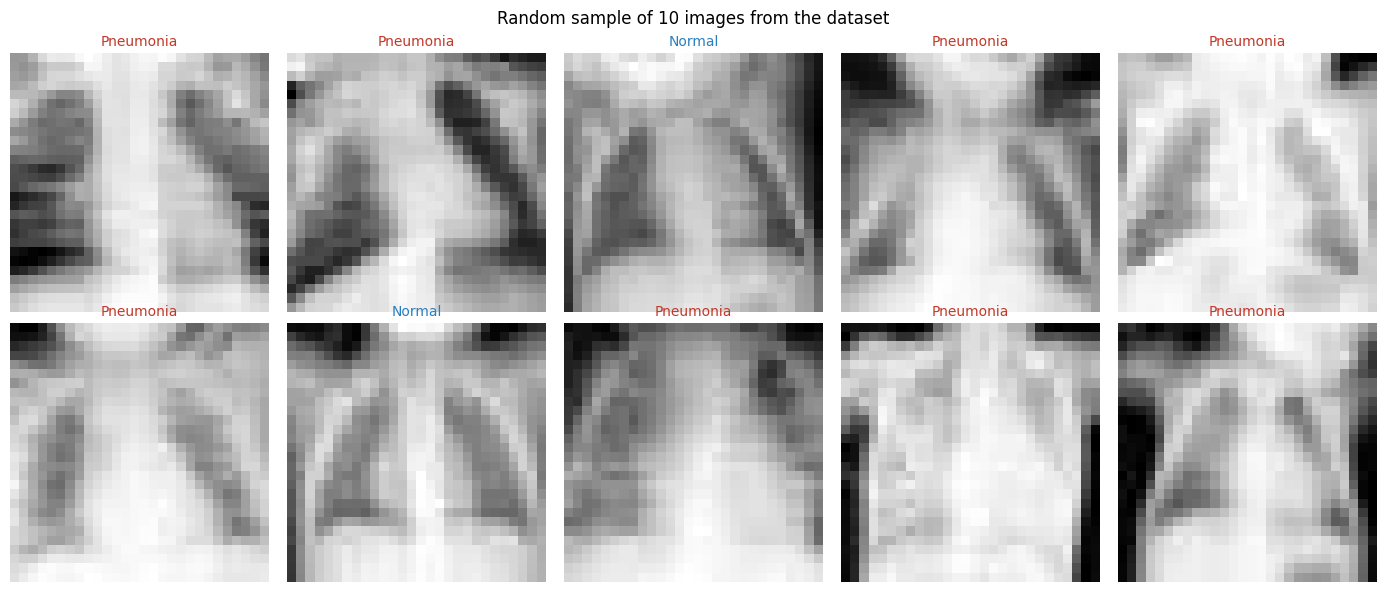

In [3]:
# Select 10 random indices from the training set (without replacement)
sample = np.random.choice(len(labels), 10, replace=False)

# Map class labels to display text and colors
label_text = {0: 'Normal', 1: 'Pneumonia'}
title_colors = {0: '#2a7fbf', 1: '#c0392b'}

# Display the 10 sampled images in a 2x5 grid
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, idx in zip(axes.flatten(), sample):
    ax.imshow(imgs[idx], cmap='gray')
    ax.set_title(label_text[labels[idx]], fontsize=10,
                 color=title_colors[labels[idx]])
    ax.axis('off')

plt.suptitle('Random sample of 10 images from the dataset', fontsize=12)
plt.tight_layout()
plt.show()

The sample obtained contains 8 pneumonia images and 2 normal ones, consistent with the dataset distribution (74.2% pneumonia). Visually, variability within each class is already apparent: not all pneumonia cases look alike nor have the same level of opacity, which anticipates that segmentation algorithms will not perform equally on all images.

### 2.2 Visual comparison between classes (5 normal vs 5 pneumonia)

To appreciate the visual differences between both classes, we select 5 images from each and arrange them in separate rows: normal on top, pneumonia below. This layout allows direct comparison of the general appearance of each class.

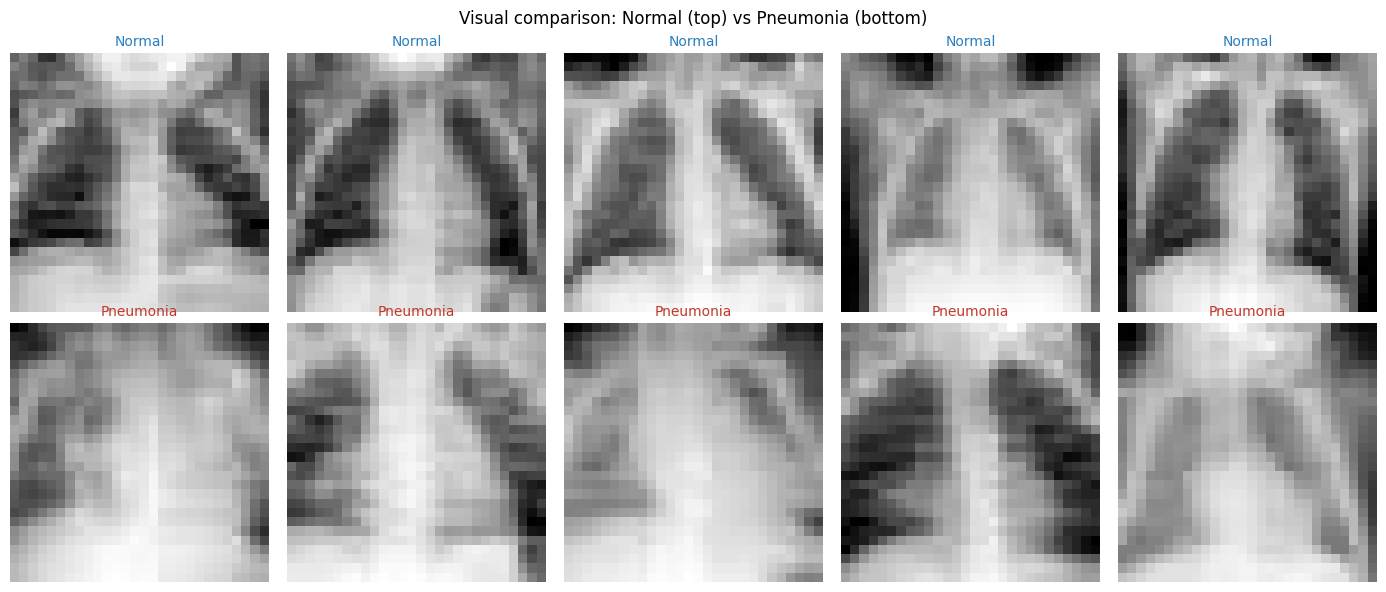

In [4]:
# Get all indices where label is pneumonia (1) or normal (0)
idx_pneumonia = np.where(labels == 1)[0]
idx_normal = np.where(labels == 0)[0]

# Randomly select 5 images from each class
idx_5p = np.random.choice(idx_pneumonia, 5, replace=False)
idx_5n = np.random.choice(idx_normal, 5, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))

# Top row: display the 5 selected normal cases
for i, idx in enumerate(idx_5n):
    axes[0][i].imshow(imgs[idx], cmap='gray')
    axes[0][i].set_title('Normal', fontsize=10,
                 color='#2a7fbf')
    axes[0][i].axis('off')

# Bottom row: display the 5 selected pneumonia cases
for i, idx in enumerate(idx_5p):
    axes[1][i].imshow(imgs[idx], cmap='gray')
    axes[1][i].set_title('Pneumonia', fontsize=10,
                 color='#c0392b')
    axes[1][i].axis('off')

plt.suptitle('Visual comparison: Normal (top) vs Pneumonia (bottom)', fontsize=12)
plt.tight_layout()
plt.show()

The visual comparison confirms that the distinction between classes is not evident in all cases. Some pneumonia images show clearly visible diffuse opacity, but others are visually very similar to normal ones. At 28x28 pixels of resolution, many diagnostic details are lost. This variability within the pneumonia class anticipates a problem we will see in segmentation: intensity-based algorithms will work in cases with clear contrast but will fail in subtle cases, which are precisely the most difficult to diagnose.

### 2.3 Class distribution and intensity statistics

We visualize the class distribution in the training set and compute the mean intensity with its standard deviation for each class. These statistics allow us to anticipate whether the two populations are distinguishable by global intensity, which is relevant for evaluating whether Otsu (which operates on the histogram) will be able to separate both classes.

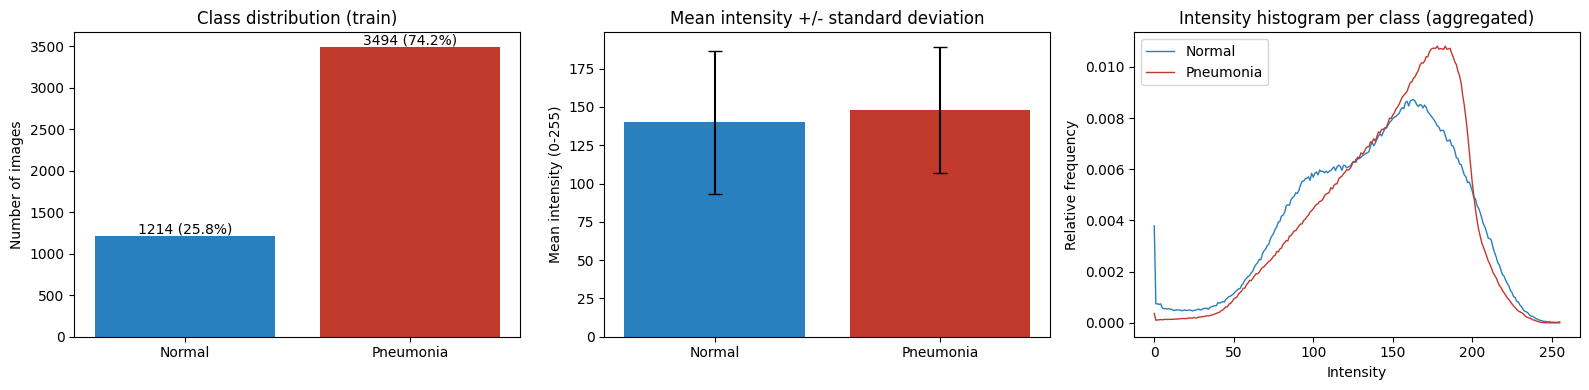

Normal:    mean = 139.9, standard deviation = 46.8
Pneumonia: mean = 147.9, standard deviation = 41.3


In [5]:
# Get unique classes and their counts
classes, counts = np.unique(labels, return_counts=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
bar_colors = ['#2a7fbf', '#c0392b']

# Plot 1: bar chart showing number of images per class
axes[0].bar(['Normal', 'Pneumonia'], counts, color=bar_colors)
# Add count and percentage labels above each bar
for i, v in enumerate(counts):
    axes[0].text(i, v + 30, f'{v} ({v/len(labels)*100:.1f}%)', ha='center', fontsize=10)
axes[0].set_ylabel('Number of images')
axes[0].set_title('Class distribution (train)')

# Compute mean and standard deviation of pixel intensities per class
mean_normal = imgs[labels == 0].mean()
std_normal = imgs[labels == 0].std()
mean_pneu = imgs[labels == 1].mean()
std_pneu = imgs[labels == 1].std()

# Plot 2: bar chart of mean intensity with error bars (std deviation)
axes[1].bar(['Normal', 'Pneumonia'], [mean_normal, mean_pneu],
            yerr=[std_normal, std_pneu], color=bar_colors, capsize=5)
axes[1].set_ylabel('Mean intensity (0-255)')
axes[1].set_title('Mean intensity +/- standard deviation')

# Plot 3: overlaid normalized histograms for both classes
for cls, color, name in [(0, '#2a7fbf', 'Normal'), (1, '#c0392b', 'Pneumonia')]:
    # Flatten all pixels of this class into a single 1D array
    class_sample = imgs[labels == cls].flatten()
    # Compute histogram with 256 bins covering the full intensity range
    hist_vals = np.histogram(class_sample, bins=256, range=(0, 255))[0]
    # Normalize to relative frequency so both classes are comparable
    axes[2].plot(hist_vals / hist_vals.sum(), color=color, label=name, linewidth=1)
axes[2].set_xlabel('Intensity')
axes[2].set_ylabel('Relative frequency')
axes[2].set_title('Intensity histogram per class (aggregated)')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f'Normal:    mean = {mean_normal:.1f}, standard deviation = {std_normal:.1f}')
print(f'Pneumonia: mean = {mean_pneu:.1f}, standard deviation = {std_pneu:.1f}')

The aggregated histograms show that the intensity distributions of both classes overlap considerably. This confirms that separation by global intensity is not trivial and anticipates the difficulty that thresholding methods (such as Otsu) will have in distinguishing pathological tissue from healthy tissue in individual images.

---
## 3. Preprocessing: Filtering Before Segmentation

### Why filtering before segmentation is necessary

Segmentation algorithms work directly on pixel intensity values. If the image contains noise, they process it as if it were real information:

- **Otsu** analyzes the histogram to find a threshold. If there are noise peaks in the histogram, the computed threshold shifts and the segmentation is incorrect.
- **Canny** computes gradients (abrupt intensity changes) to detect edges. A noisy pixel generates an abrupt intensity change that Canny interprets as a real edge.
- **Watershed** interprets intensities as altitudes. A noisy pixel creates an artificial "peak" that Watershed treats as a separate region.

This is why it is necessary to reduce noise and improve contrast before segmenting: so that the algorithms work on real information and not on artifacts.

### The four filters applied

We apply four filters, each with a different purpose. We use 3x3 kernels because in 28x28 images a larger kernel would lose too much information.

**Gaussian filter** (`cv2.GaussianBlur`): a smoothing (low-pass) filter that reduces general noise. It weights neighboring pixels with Gaussian bell-shaped weights: the center pixel has more weight than distant neighbors. The result is a smoothing that better preserves gradual intensity transitions than a simple average.

In radiological imaging, this type of general noise is frequent when the radiation dose is low, as occurs in pediatric radiography where the dose is reduced to protect the patient.

**Median filter** (`cv2.medianBlur`): replaces each pixel by the median (the central value) of its 3x3 neighborhood. Its advantage over the Gaussian is that it ignores extreme values: if a pixel has a very high or very low intensity due to noise, the median simply does not select it. This is why it is especially effective against "salt and pepper" noise (isolated white or black dots).

In pediatric radiology, this impulsive noise can appear due to patient movement during exposure, common in small children who do not cooperate during acquisition.

**Histogram equalization** (`cv2.equalizeHist`): does not reduce noise but improves contrast. It redistributes intensities to occupy the full available range [0, 255]. The goal is for the cumulative histogram to approximate a straight line, meaning a more uniform distribution of intensities. This helps Otsu better distinguish two pixel populations. Its limitation is that it is global: it improves the entire image with the same criterion, which can overexpose some areas when trying to correct others.

In a chest X-ray, for example, improving the lung fields (dark) can overexpose the mediastinum (dense), losing detail in that area.

**CLAHE** (`cv2.createCLAHE`): an adaptive version of equalization. Instead of equalizing the entire image with a single adjustment, it divides it into small tiles (in our case 4x4) and equalizes each one independently. The clipLimit parameter (2.0) limits how much contrast can be amplified in each tile, to prevent noise amplification. The result is a contrast enhancement that adapts to each zone of the image.

This local approach makes sense in radiological imaging because a chest X-ray has zones with very different densities (aerated lung, dense mediastinum, ribs) that need different contrast adjustments.

### Selection of three representative cases

For the rest of the work we select three images that will accompany the entire analysis: a normal image as reference, one with moderate radiological alteration, and one with intense alteration (both labeled as pneumonia in the dataset). This progression from least to most affected allows comparing how the pipeline responds under different conditions.

### Comparative visualization

We apply the four filters to the three selected cases and show the result alongside the histogram of each version. The histograms allow us to see how each filter modifies the intensity distribution, which directly affects the threshold that Otsu will compute in the segmentation phase.

In [6]:
def compare_filters(img):
    """Applies four filters and shows results with histograms."""
    # Ensure uint8 type for OpenCV functions
    img_uint8 = img.astype(np.uint8)
    # Gaussian blur with 3x3 kernel and sigma=0.5 — smooths noise
    gaussian = cv2.GaussianBlur(img_uint8, (3, 3), 0.5)
    # Median filter with 3x3 window — removes impulse noise without blurring edges
    median = cv2.medianBlur(img_uint8, 3)
    # Global histogram equalization — spreads intensities uniformly across 0-255
    equalized = cv2.equalizeHist(img_uint8)
    # CLAHE: adaptive local equalization, clipLimit=2.0 prevents noise amplification
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
    # Apply CLAHE to the image
    clahe_img = clahe.apply(img_uint8)

    # List of (label, image) tuples for plotting
    filters = [
        ('Original', img_uint8),
        ('Gaussian (3x3)', gaussian),
        ('Median (3x3)', median),
        ('Global equalization', equalized),
        ('CLAHE (clip=2.0)', clahe_img),
    ]

    fig, axes = plt.subplots(2, 5, figsize=(18, 6))
    for i, (title, img_f) in enumerate(filters):
        # Top row: display filtered image in grayscale
        axes[0][i].imshow(img_f, cmap='gray')
        axes[0][i].set_title(title, fontsize=9)
        axes[0][i].axis('off')

        # Bottom row: compute and plot intensity histogram (256 bins)
        hist = cv2.calcHist([img_f], [0], None, [256], [0, 256])
        axes[1][i].plot(hist, color='black', linewidth=0.8)
        axes[1][i].set_xlim([0, 255])
        axes[1][i].set_xlabel('Intensity', fontsize=8)
        if i == 0:
            axes[1][i].set_ylabel('Frequency', fontsize=8)

    plt.tight_layout()
    plt.show()
    # Return the CLAHE result for use in subsequent segmentation steps
    return clahe_img

**Case 1: Normal**

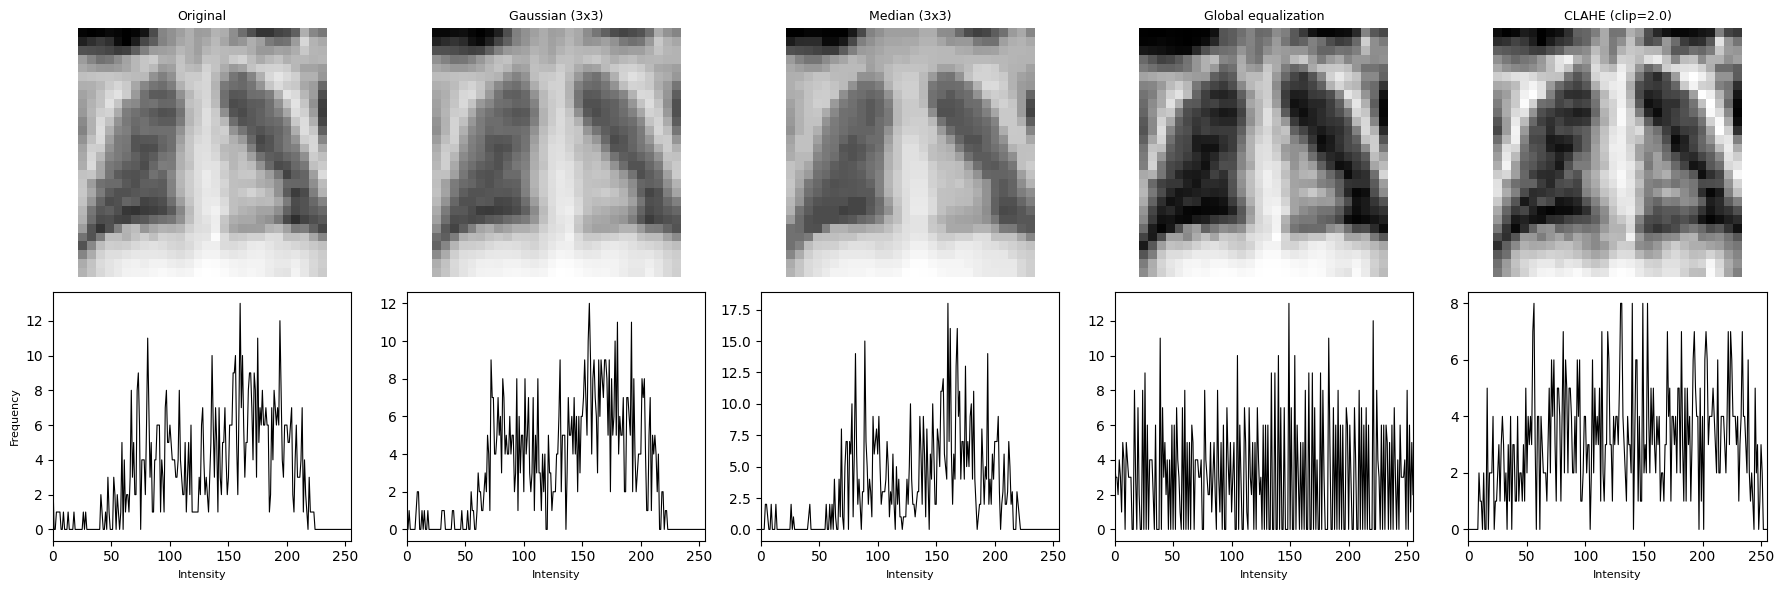

In [7]:
# Select case 1: a normal chest X-ray (3rd from the normal selection)
img_normal_case = imgs[idx_5n[2]]
# Apply all four filters and return the CLAHE-preprocessed result
_ = compare_filters(img_normal_case)

**Case 2: Moderate radiological alteration (labeled as pneumonia)**

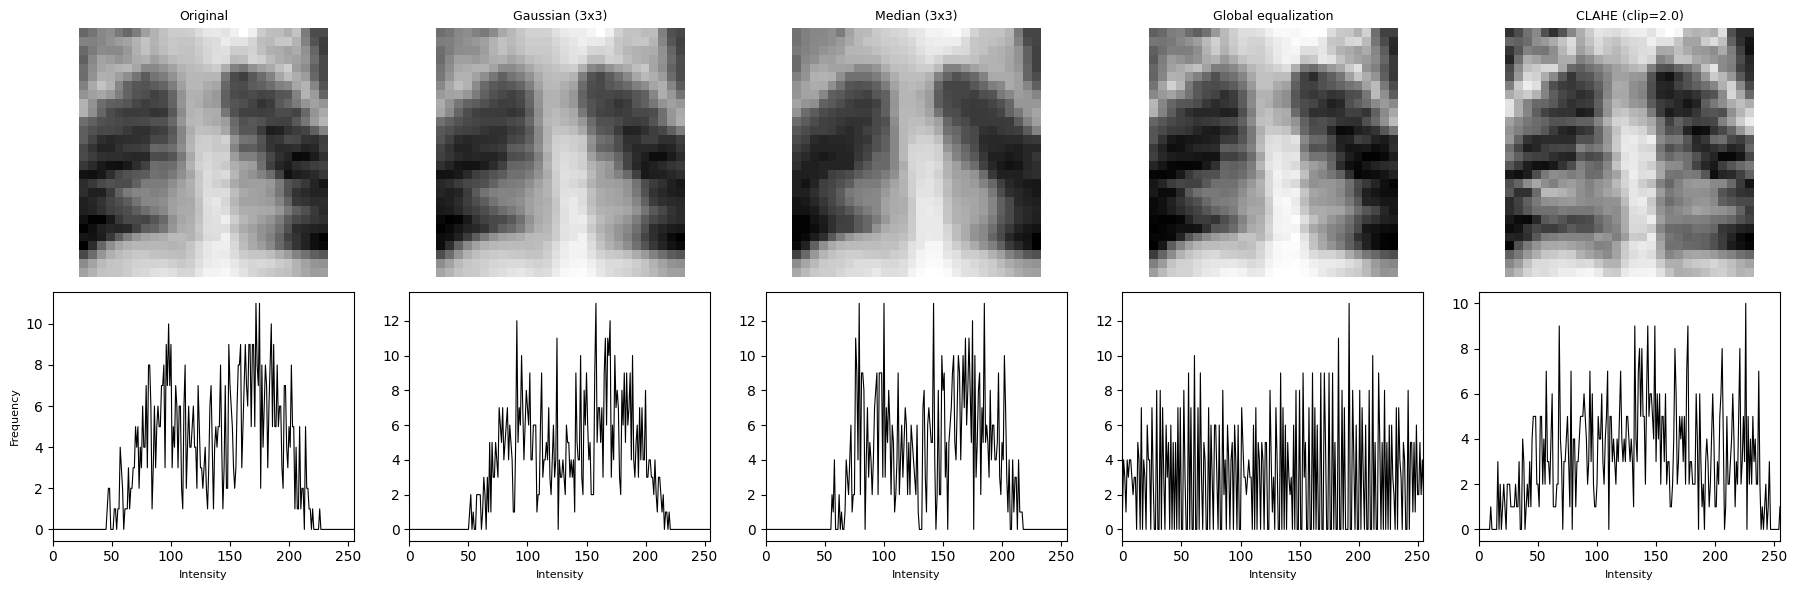

In [8]:
# Select case 2: a pneumonia case with moderate radiological alteration
img_moderate = imgs[idx_5p[3]]
# Apply all four filters and return the CLAHE-preprocessed result
_ = compare_filters(img_moderate)

**Case 3: Intense radiological alteration (labeled as pneumonia)**

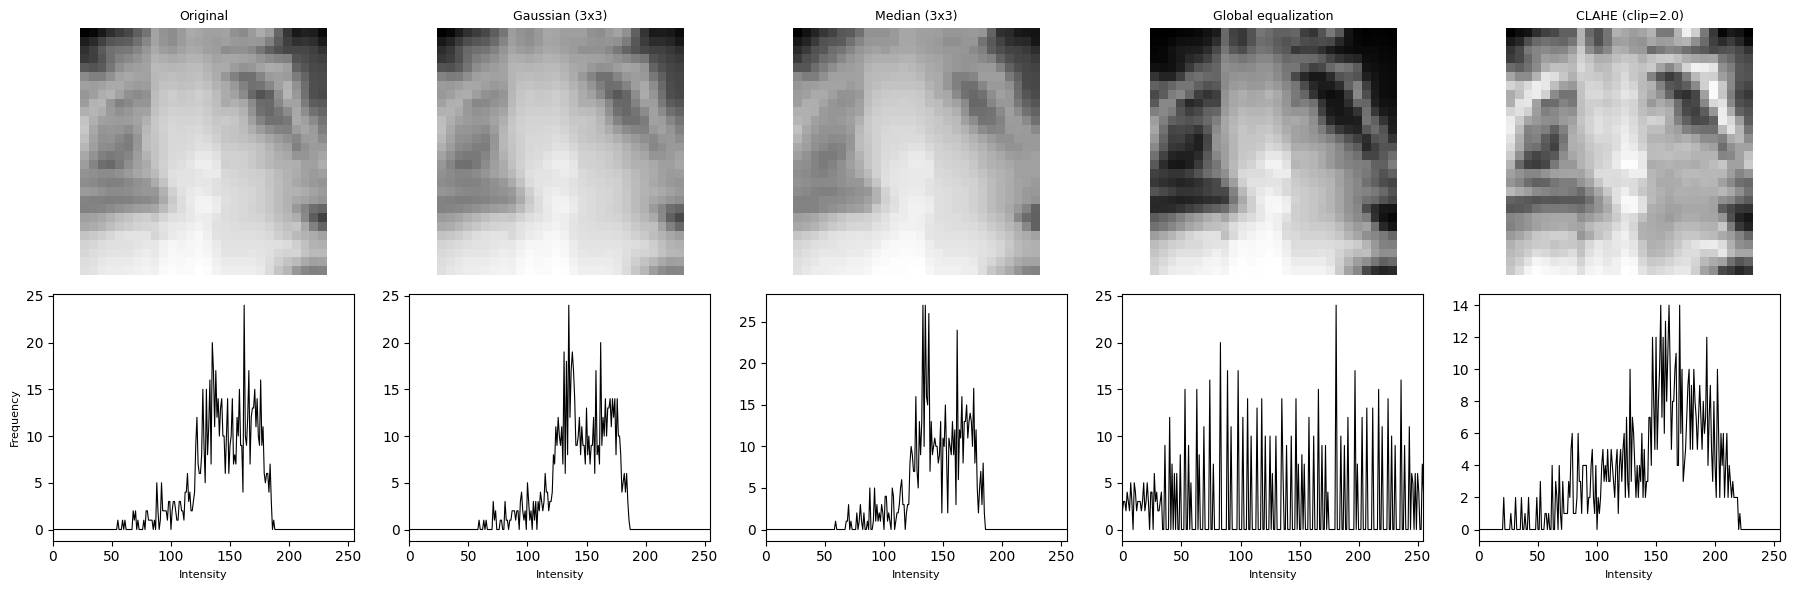

In [9]:
# Select case 3: a pneumonia case with intense radiological alteration
img_intense = imgs[idx_5p[2]]
# Apply all four filters and return the CLAHE-preprocessed result
_ = compare_filters(img_intense)

**Observations on the results:**

The Gaussian and median filters produce subtle changes in the three cases. At this resolution (28x28) the high-frequency noise is already limited and the effect of smoothing filters is less evident than in full clinical resolution images.

Global equalization redistributes the histogram aggressively in all three cases, expanding the full range [0, 255]. CLAHE achieves a similar effect but with more local control.

The most relevant finding is in the histograms. Case 1 (normal) shows a relatively uniform distribution. Case 2 (moderate alteration) has a more spread histogram without clear groupings. Case 3 (intense alteration) shows a histogram with two more marked intensity groupings, which could correspond to the contrast between affected tissue and the rest. Its overall denser appearance could relate both to the intensity of the alteration and to the characteristics of a smaller pediatric thorax. This progression anticipates that Otsu will find a more defined threshold in case 3 than in the other two.

For the segmentation that follows, we select CLAHE as preprocessing for its best balance between contrast enhancement and local detail preservation.

---
## 4. Segmentation

Segmentation divides the image into homogeneous regions with meaning, grouping pixels by intensity, gradient, or proximity criteria. Several families of techniques exist: thresholding (Otsu), edge detection (Sobel, Canny), region-based methods (region growing, Watershed), and statistical methods (K-Means, GMM).

### Justification of the selected techniques

We apply three complementary approaches:

- **Otsu** as a first binarization step, because it selects the threshold automatically from the histogram, without manual intervention.
- **Sobel and Canny** for edge detection, because edges correspond to interfaces between tissues of different density and are the first thing a radiologist looks for when reading a film.
- **Watershed** as a region-based method, because it can separate objects that touch or are very close together. This is relevant in multilobar or bilateral pneumonias where several opacities merge and Otsu would fuse them into a single region.

We did not apply K-Means or GMM because they are more suitable for color segmentation (as in color image segmentation). In single-channel (grayscale) images with low resolution, intensity clustering does not offer significant advantage over thresholding.

### 4.1 Otsu Thresholding

The Otsu algorithm iterates over all possible thresholds (0 to 255) and selects the one that maximizes the variance between the two resulting pixel classes (background and foreground). This is equivalent to minimizing the intraclass variance: it finds the cutoff point that makes pixels within each group as homogeneous as possible among themselves, and as different as possible from the other group.

This method assumes the histogram is bimodal (two distinguishable populations). When this condition holds, the threshold is robust and the result is good. When the histogram has a single mode or the two populations overlap, Otsu selects a threshold that does not separate anything usefully. We will see both situations in the case analysis.

We show the preprocessed image, its histogram with the Otsu threshold marked in red, and the resulting binary mask.

In [10]:
def apply_otsu(img):
    """Applies Otsu thresholding and shows image, histogram, and result."""
    # Apply Otsu thresholding — automatically finds optimal threshold from histogram
    threshold_val, mask = cv2.threshold(
        img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Compute intensity histogram (256 bins, full 0-255 range)
    hist = cv2.calcHist([img], [0], None, [256], [0, 256])

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # Panel 1: display the preprocessed input image
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title('Preprocessed image (CLAHE)')
    axes[0].axis('off')

    # Panel 2: histogram with vertical red line at the Otsu threshold
    axes[1].plot(hist, color='black', linewidth=0.8)
    axes[1].axvline(x=threshold_val, color='red', linestyle='dashed',
                    linewidth=2, label=f'Otsu threshold: {threshold_val:.0f}')
    axes[1].set_title('Histogram with threshold')
    axes[1].set_xlabel('Intensity')
    axes[1].set_ylabel('Frequency')
    axes[1].legend()

    # Panel 3: display the resulting binary mask
    axes[2].imshow(mask, cmap='gray')
    axes[2].set_title('Binary mask (Otsu)')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    return threshold_val, mask

**Case 1: Normal**

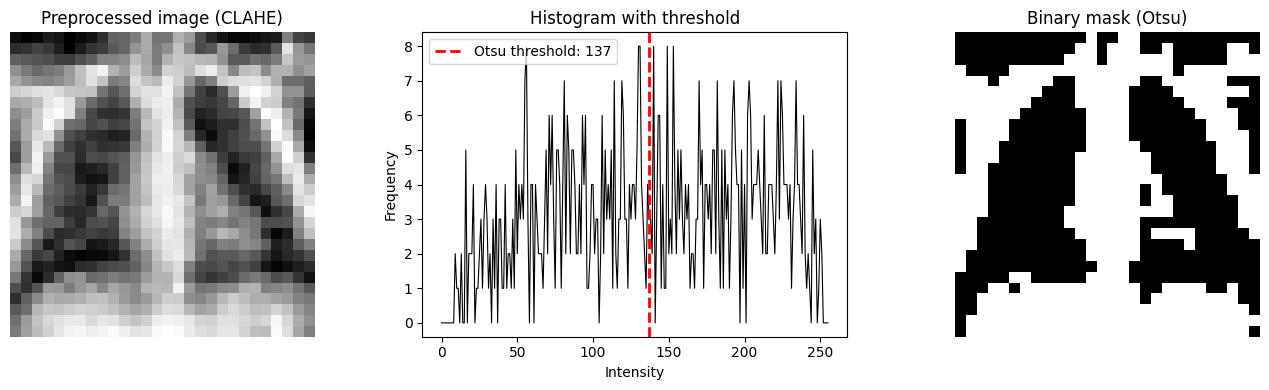

Otsu threshold case 1: 137


In [11]:
# Create CLAHE object — used to preprocess all three cases before segmentation
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))

# Preprocess case 1 (normal) with CLAHE and apply Otsu
img_pre_1 = clahe.apply(img_normal_case.astype(np.uint8))
threshold_1, mask_1 = apply_otsu(img_pre_1)
print(f'Otsu threshold case 1: {threshold_1:.0f}')

**Case 2: Moderate alteration**

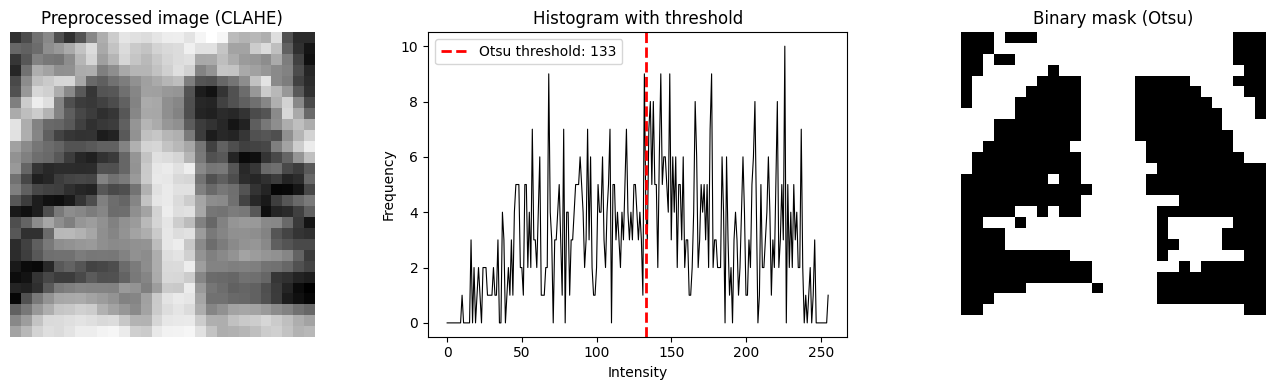

Otsu threshold case 2: 133


In [12]:
# Preprocess case 2 (moderate alteration) with CLAHE and apply Otsu
img_pre_2 = clahe.apply(img_moderate.astype(np.uint8))
threshold_2, mask_2 = apply_otsu(img_pre_2)
print(f'Otsu threshold case 2: {threshold_2:.0f}')

**Case 3: Intense alteration (labeled as pneumonia)**

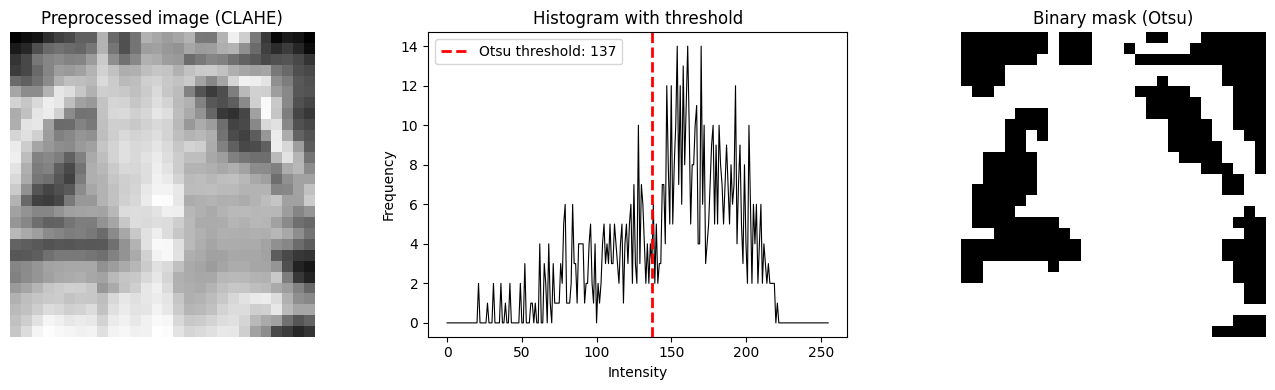

Otsu threshold case 3: 137


In [13]:
# Preprocess case 3 (intense alteration) with CLAHE and apply Otsu
img_pre_3 = clahe.apply(img_intense.astype(np.uint8))
threshold_3, mask_3 = apply_otsu(img_pre_3)
print(f'Otsu threshold case 3: {threshold_3:.0f}')

**Observations on Otsu in the three cases:**

The computed thresholds are similar (137, 133, and 137), reflecting that CLAHE homogenized the intensity distributions. All three histograms show distributions without clear bimodality, which limits Otsu's ability to optimally separate pixel populations. Despite this, the resulting binary masks capture recognizable anatomical information.

In case 1 (normal), the mask allows distinguishing the cardiac silhouette in central position slightly to the left and the bilateral lung fields preserved. In case 2 (moderate alteration), an opacity zone is observed in the right lung field that does not appear in the normal case, while the rest of the lung fields remain relatively preserved. In case 3 (intense alteration), the cardiac silhouette appears expanded, possibly due to the confluence of adjacent opacities, and both lung fields appear reduced. This is consistent with more extensive involvement.

It is important to remember that Otsu does not distinguish between normal anatomy and pathology: it separates light pixels from dark ones. That the masks reflect recognizable anatomical structures is a useful result, but not a diagnosis. The following pipeline steps (edge detection and Watershed) will attempt to delineate these regions more precisely.

### 4.2 Edge Detection: Sobel and Canny

Edges in an image correspond to zones where intensity changes rapidly. In a chest X-ray, these transitions mark interfaces between tissues of different radiological density: the pleura against the lung parenchyma, the borders of the cardiac silhouette, the ribs against the lung field, and pathological opacities against surrounding tissue.

**Sobel** computes the intensity gradient in the horizontal (Gx) and vertical (Gy) directions using 3x3 kernels. The gradient magnitude G = sqrt(Gx^2 + Gy^2) indicates the edge strength at each point. It is computationally simple but sensitive to noise because it computes gradients without prior smoothing.

**Canny** is a multi-stage detector designed to be more robust. Its four steps are:
1. Gaussian smoothing to reduce noise
2. Gradient computation (magnitude and direction)
3. Non-maximum suppression: thins edges to 1 pixel wide, keeping only the maximum gradient point in each direction perpendicular to the edge
4. Hysteresis thresholding: uses two thresholds (TH high and TL low). Pixels with gradient above TH are definite edges. Those between TL and TH are kept only if connected to a definite edge. Those below TL are discarded.

We use TL=30 and TH=100 to capture edges in these low-contrast images. In the last column we overlay Canny edges on the original image in red to visualize which structures are detected.

In [14]:
def detect_edges(img):
    """Applies Sobel and Canny on the preprocessed image."""
    # Sobel horizontal gradient (dx=1) — detects vertical edges
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    # Sobel vertical gradient (dy=1) — detects horizontal edges
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    # Combined gradient magnitude: sqrt(Gx^2 + Gy^2)
    sobel_mag = cv2.magnitude(sobelx, sobely)

    # Canny edge detector with low threshold=30 and high threshold=100
    canny = cv2.Canny(img, 30, 100)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    # Panel 1: preprocessed input image
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title('Image (CLAHE)')
    axes[0].axis('off')

    # Panel 2: Sobel gradient magnitude
    axes[1].imshow(sobel_mag, cmap='gray')
    axes[1].set_title('Sobel (magnitude)')
    axes[1].axis('off')

    # Panel 3: Canny binary edge map
    axes[2].imshow(canny, cmap='gray')
    axes[2].set_title('Canny (TL=30, TH=100)')
    axes[2].axis('off')

    # Panel 4: overlay Canny edges in red on the original grayscale image
    overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    overlay[canny > 0] = [255, 0, 0]  # Paint edge pixels red
    axes[3].imshow(overlay)
    axes[3].set_title('Canny overlay')
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()

**Case 1: Normal**

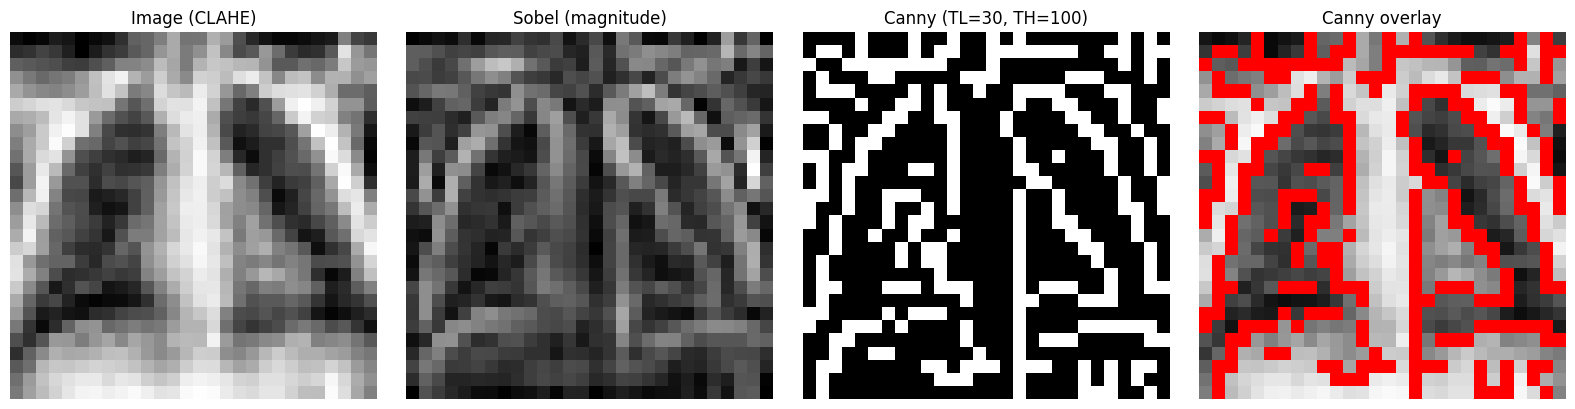

In [15]:
# Run edge detection on the normal case
detect_edges(img_pre_1)

**Case 2: Moderate alteration (labeled as pneumonia)**

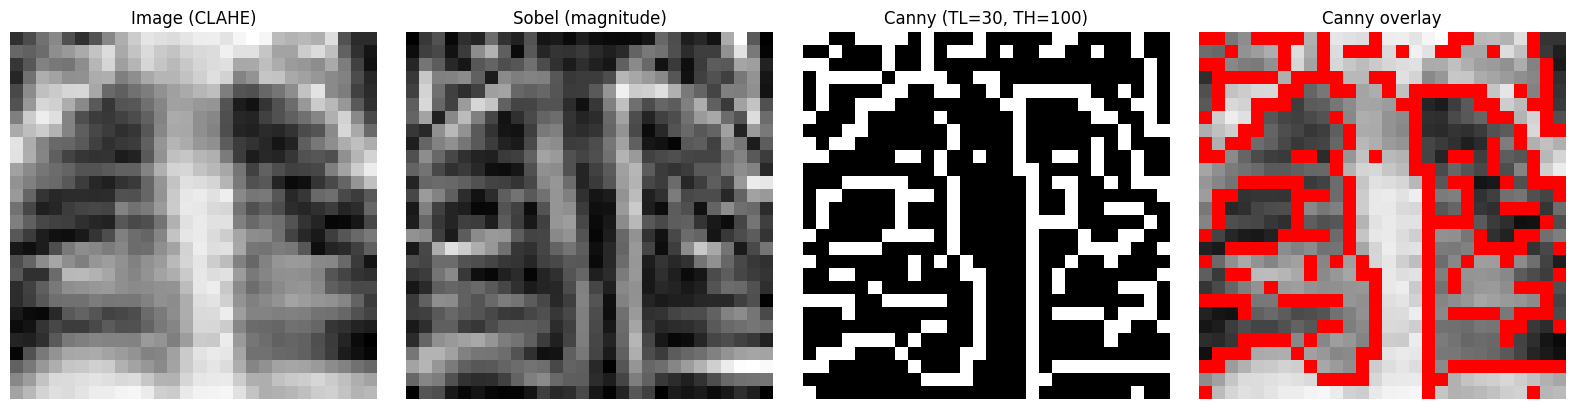

In [16]:
# Run edge detection on the moderate alteration case
detect_edges(img_pre_2)

**Case 3: Intense alteration (labeled as pneumonia)**

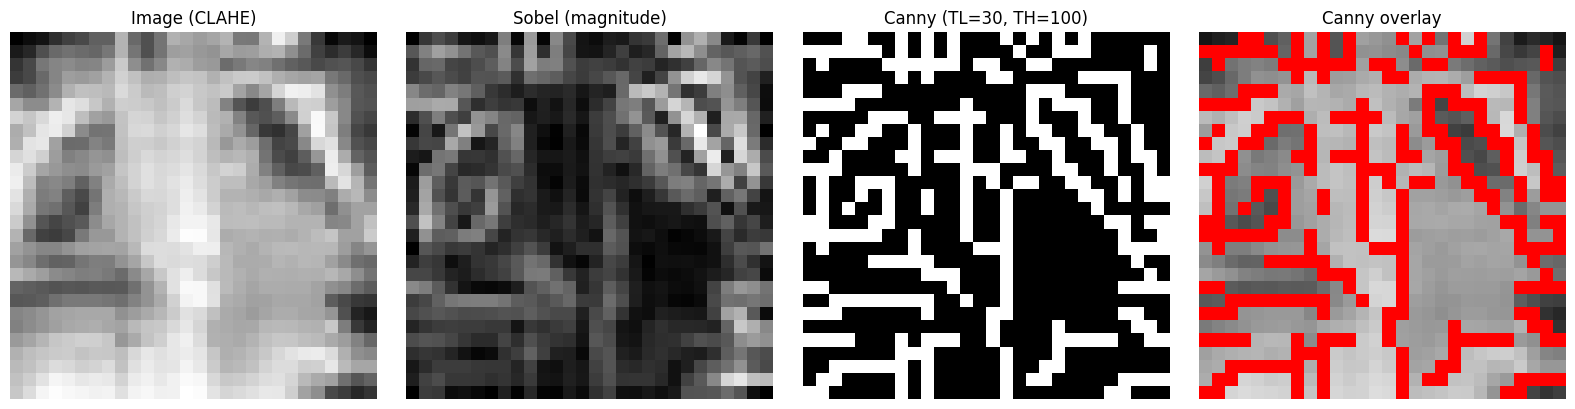

In [17]:
# Run edge detection on the intense alteration case
detect_edges(img_pre_3)

**Observations on edge detection:**

At this resolution (28x28 pixels), Sobel and Canny produce results that are visually difficult to interpret. Canny detects edges across practically the entire image because each transition between adjacent pixels represents a proportionally large intensity change. In case 1 (normal), with effort one can discern the cardiac silhouette and the lung field boundaries, plus the thoracic wall borders. In cases 2 and 3 (moderate and intense alteration) edges accumulate without a clear structure.

This does not mean that Sobel and Canny are inadequate techniques. In full clinical resolution images, where there are thousands of pixels between structures, these detectors produce sharp and useful edges. The limitation here is the dataset resolution, not the algorithms.

Despite their limited direct visual utility in these images, edge detection fulfills a function within the pipeline: Canny is an internal part of more complex segmentation algorithms.

### 4.3 Complete Watershed Pipeline

Watershed treats the grayscale image as a topographic map where each pixel's intensity represents its altitude. The algorithm simulates a flood: from internal markers (the object centers), "water" fills each basin until it meets the boundary with the neighboring basin. Those boundaries are the segmentation lines.

The complete pipeline requires several preprocessing steps to generate the initial markers that Watershed needs. The sequence is as follows:

1. **Otsu thresholding** to obtain an initial binary mask separating light from dark regions
2. **Morphological opening** (erosion followed by dilation, `cv2.morphologyEx` with `MORPH_OPEN`): removes small noise artifacts without altering the shape of large objects. Erosion shrinks regions removing fine noise, and the subsequent dilation restores the original size of surviving objects
3. **Dilation** to expand the mask and determine the sure background: pixels that certainly do not belong to any object
4. **Distance transform** (`cv2.distanceTransform`): for each white pixel, computes its Euclidean distance to the nearest border. The local maxima of the distance map correspond to the object centers (the points farthest from any boundary)
5. **Thresholding of the distance map** to obtain the sure foreground: only pixels whose distance exceeds a percentage of the maximum are considered object centers with certainty
6. **Unknown region**: the difference between sure background and sure foreground. These are pixels we do not know with certainty which region they belong to. This is what Watershed must resolve
7. **Connected components** (`cv2.connectedComponents`): assigns a distinct numerical label to each group of adjacent pixels in the sure foreground. These labels are Watershed's initial markers
8. **Watershed** (`cv2.watershed`): expands each marker to its natural boundary, marking borders between regions with the value -1

We visualize the 9 steps in a 3x3 panel, following the standard Watershed visualization layout.

**Important note:** Watershed has no knowledge of anatomy or pathology. It will segment all contrast regions it finds: ribs, cardiac silhouette, hemidiaphragms, and also opacities if present. Without reference masks indicating where pathology is, the result is exploratory, not diagnostic.

In [18]:
def watershed_pipeline(img):
    """Complete Watershed pipeline on preprocessed image."""
    # Step 1: Otsu thresholding — binarize the image automatically
    ret, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Step 2: create a 3x3 structuring element for morphological operations
    kernel = np.ones((3, 3), np.uint8)
    # Morphological opening (erosion then dilation) — removes small noise artifacts
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)

    # Step 3: dilate the opened mask to obtain the sure background region
    sure_bg = cv2.dilate(opening, kernel, iterations=2)

    # Step 4: compute euclidean distance from each white pixel to nearest black border
    dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)

    # Step 5: threshold at 30% of max distance to find sure foreground (object centers)
    if dist_transform.max() > 0:
        ret_fg, sure_fg = cv2.threshold(
            dist_transform, 0.3 * dist_transform.max(), 255, 0
        )
    else:
        # If distance transform is all zeros, no foreground can be found
        sure_fg = np.zeros_like(opening)

    # Convert sure foreground to uint8 for cv2.subtract compatibility
    sure_fg = np.uint8(sure_fg)
    # Unknown region = area between sure background and sure foreground
    unknown = cv2.subtract(sure_bg, sure_fg)

    # Step 6: label connected components in the sure foreground as markers
    ret_cc, markers = cv2.connectedComponents(sure_fg)
    # Shift labels by 1 so background=1 (0 means "unknown" for watershed)
    markers = markers + 1
    # Mark the unknown region as 0 — watershed will determine these pixels
    markers[unknown == 255] = 0
    # Cast to int32 as required by cv2.watershed
    markers = np.int32(markers)

    # Convert grayscale to BGR — watershed requires 3-channel input
    img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    # Apply watershed algorithm — marks boundaries between regions as -1
    markers = cv2.watershed(img_color, markers)

    # Create a colored visualization of the marker regions
    markers_vis = markers.copy()
    markers_vis[markers_vis == -1] = 0  # Boundaries to 0 for visualization
    # Scale marker labels and apply JET colormap for visual distinction
    markers_colored = cv2.applyColorMap(
        np.uint8(np.clip(markers_vis * 15, 0, 255)), cv2.COLORMAP_JET
    )

    # Draw watershed boundaries in red on the original image
    result = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    result[markers == -1] = [0, 0, 255]  # Red in BGR

    # Display all 9 steps in a 3x3 grid
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    axes = axes.flatten()

    steps = [
        ('1. Original image', img, 'gray'),
        ('2. Otsu thresholding', thresh, 'gray'),
        ('3. Morphological opening', opening, 'gray'),
        ('4. Sure background', sure_bg, 'gray'),
        ('5. Distance transform', dist_transform, 'gray'),
        ('6. Sure foreground', sure_fg, 'gray'),
        ('7. Unknown region', unknown, 'gray'),
        ('8. Markers', markers_colored, None),
        ('9. Watershed result', result, None),
    ]

    for i, (title, image, cmap) in enumerate(steps):
        if cmap:
            axes[i].imshow(image, cmap=cmap)
        else:
            # Convert BGR to RGB for correct color display in matplotlib
            axes[i].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        axes[i].set_title(title, fontsize=10)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

    return markers

**Case 1: Normal**

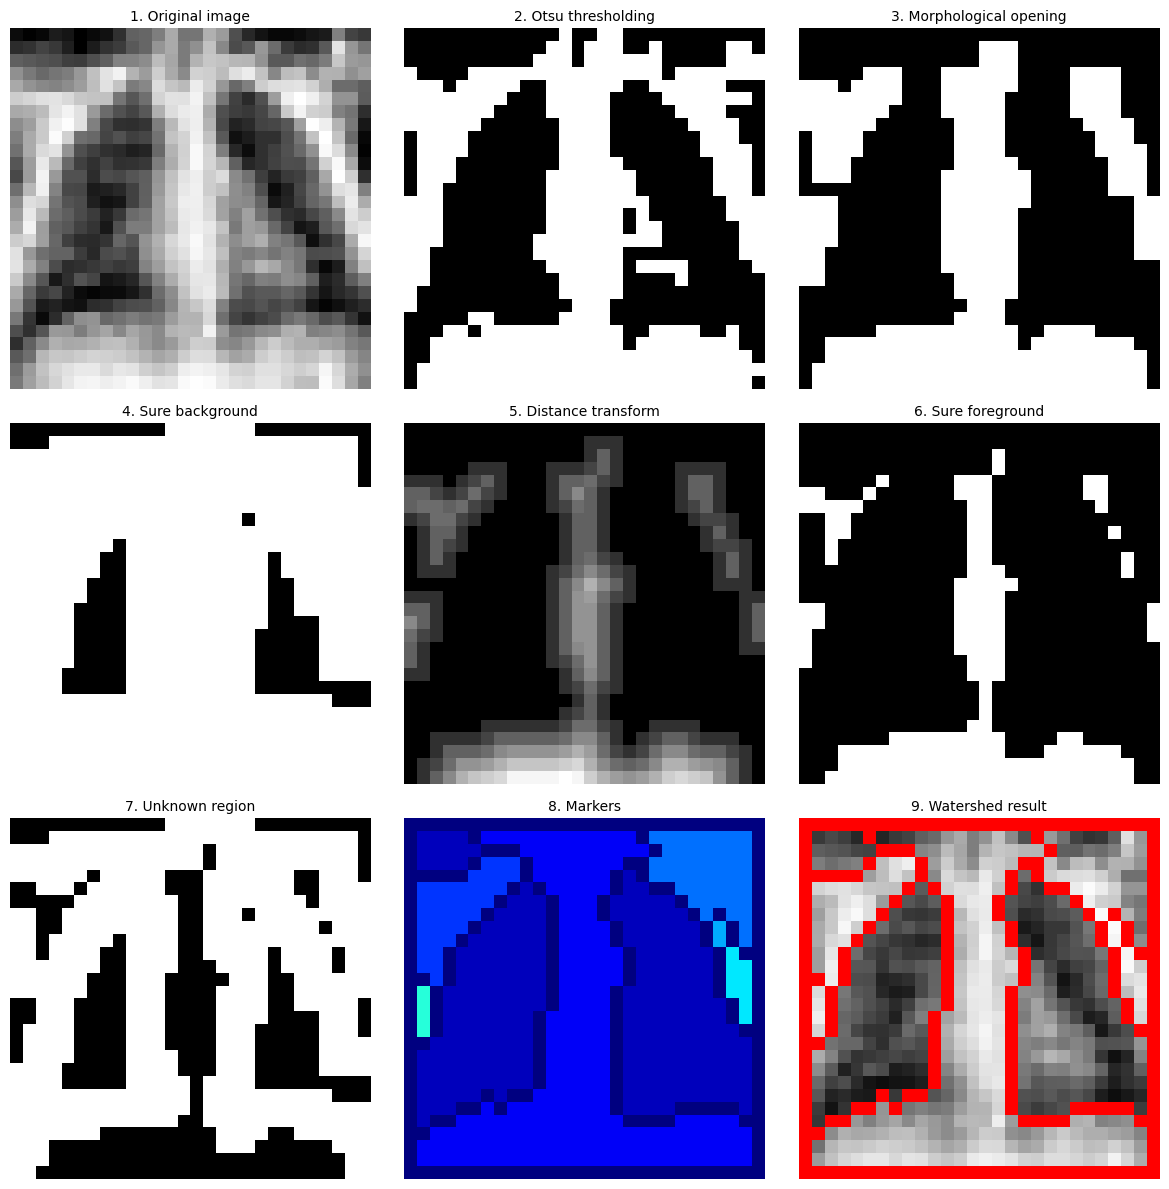

Regions detected: 7


In [19]:
# Run the full Watershed pipeline on the normal case
markers_1 = watershed_pipeline(img_pre_1)
# Count unique marker labels (subtract 1 to exclude background)
print(f'Regions detected: {len(np.unique(markers_1)) - 1}')

**Case 2: Moderate alteration**

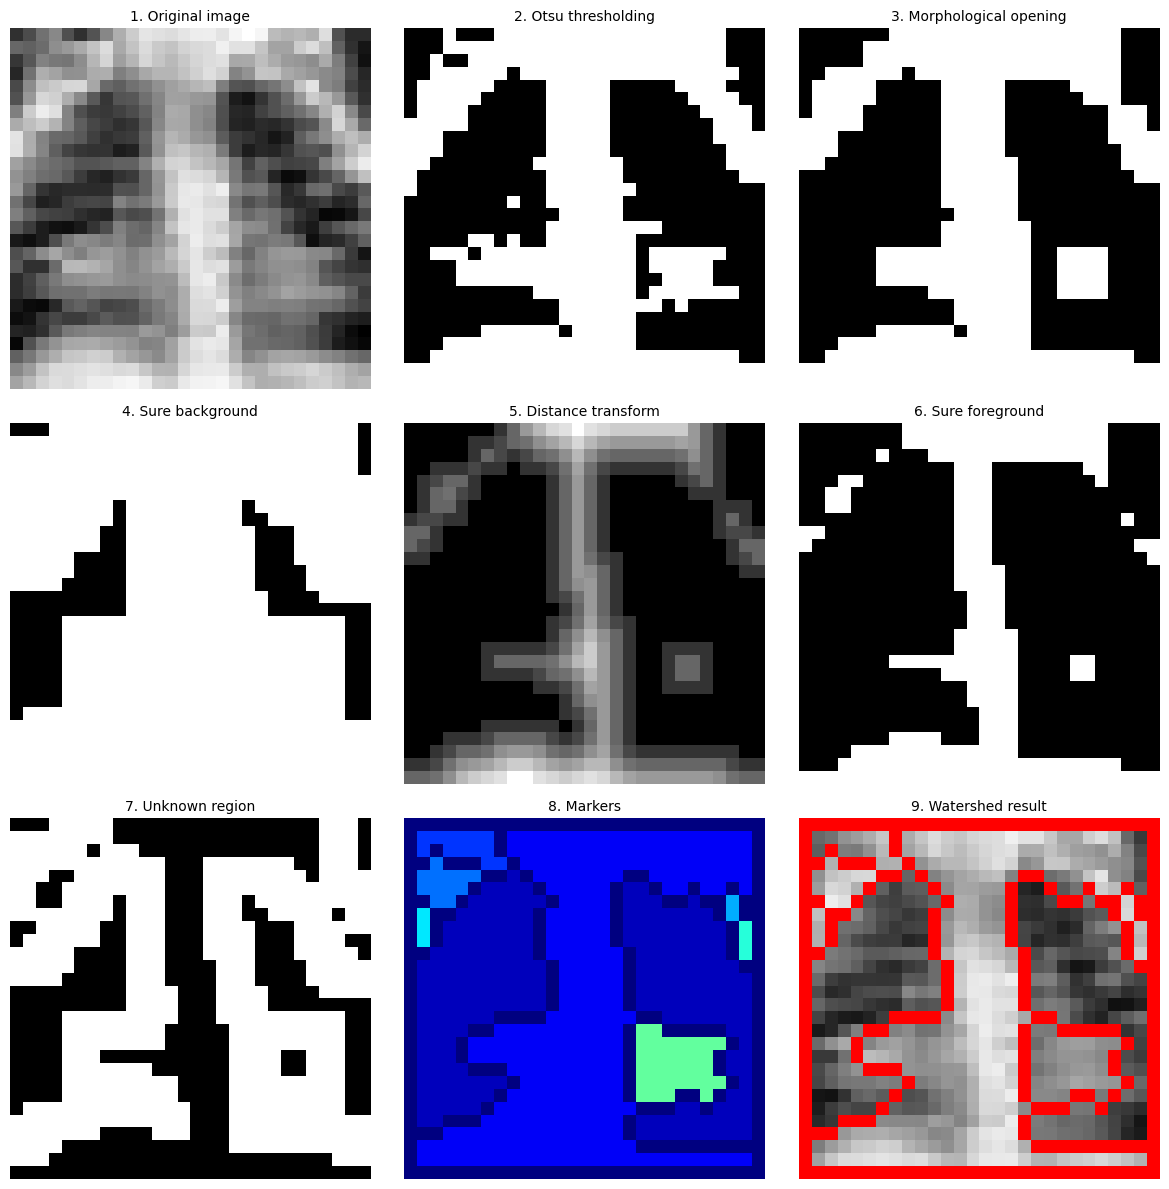

Regions detected: 8


In [20]:
# Run the full Watershed pipeline on the moderate alteration case
markers_2 = watershed_pipeline(img_pre_2)
print(f'Regions detected: {len(np.unique(markers_2)) - 1}')

**Case 3: Intense alteration**

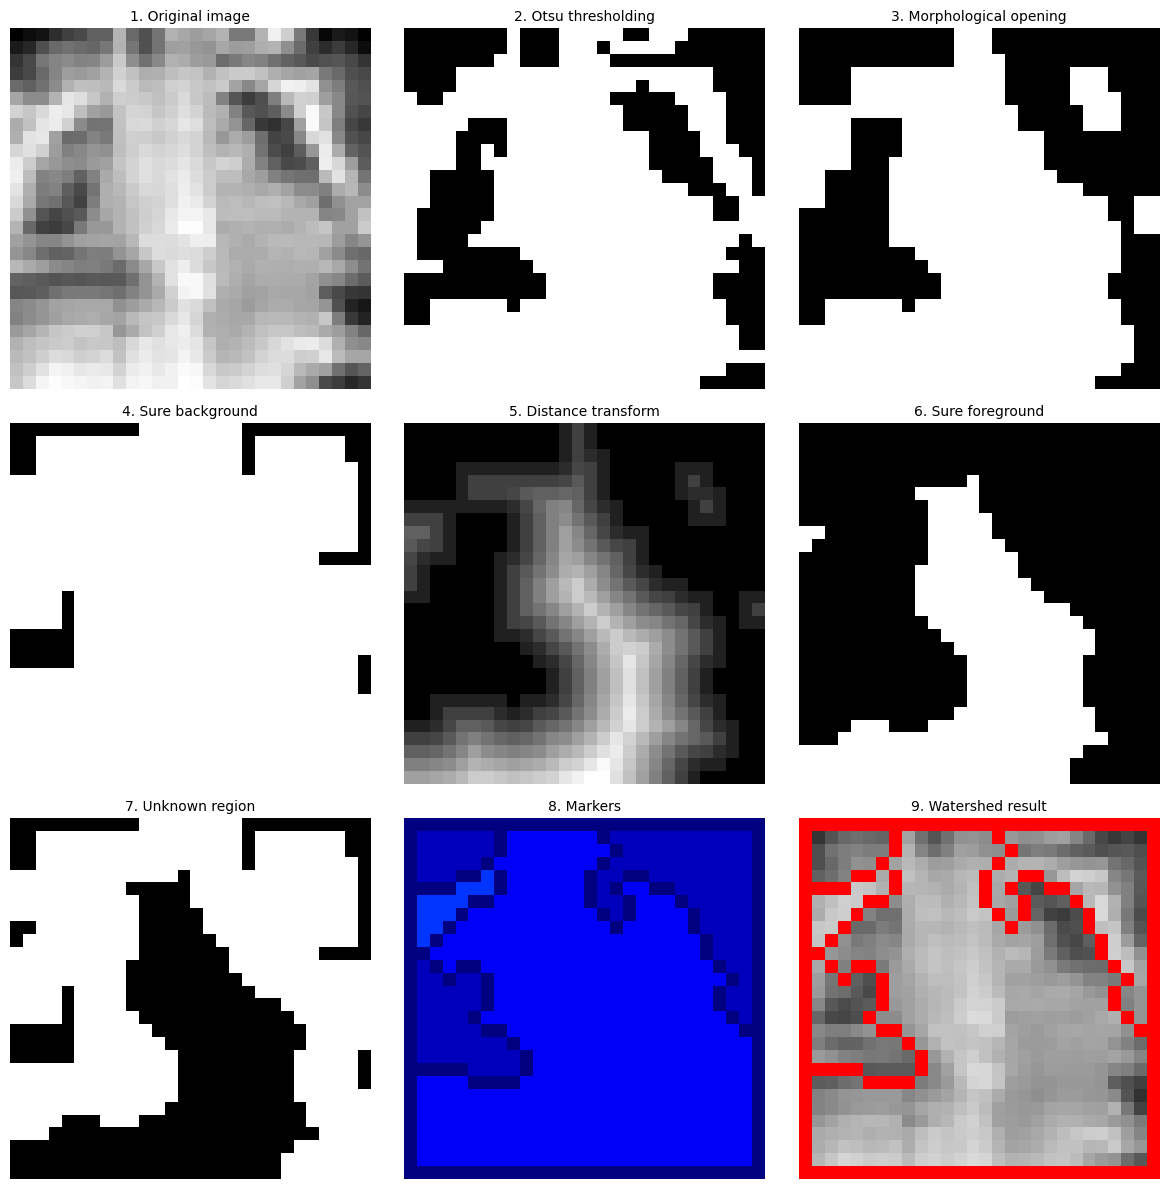

Regions detected: 3


In [21]:
# Run the full Watershed pipeline on the intense alteration case
markers_3 = watershed_pipeline(img_pre_3)
print(f'Regions detected: {len(np.unique(markers_3)) - 1}')

**Observations on Watershed in the three cases:**

Watershed detected 7 regions in the normal case, 8 in the moderate alteration, and 3 in the intense alteration. We reduced the sure foreground threshold from 0.5 to 0.3 compared to the typical default value, because at 28x28 pixels the original threshold was too demanding and generated too few markers.

In case 1 (normal), Watershed boundaries partially delineate the main anatomical structures: the lung fields are recognizable, although the cardiac silhouette in its slightly left position is not clearly delineated, and the thorax borders are marked. In case 2 (moderate alteration), it detects more regions and identifies the right lung field opacity zone as a differentiated region from the adjacent lung field. In case 3 (intense alteration), it only distinguishes 3 regions because the extensive opacity homogenizes the image and the distance transform cannot find separate centers.

This progression makes sense: the more extensive the alteration, the less internal contrast there is and the fewer regions Watershed can separate. The algorithm works best when there are differentiated objects with clear borders between them, as in typical segmentation examples with well-separated objects. In X-rays with confluent opacities, regions merge and the pipeline loses discrimination capability.

---
## 5. Segmentation Evaluation: Jaccard and Dice

Segmentation quality is evaluated by comparing the algorithm's result with a reference segmentation (ground truth) performed by a human expert. The two main metrics are:

**Jaccard Index (Intersection over Union, IoU):** measures the proportion of intersection between the obtained segmentation and the reference, divided by the union of both.

$$\text{Jaccard} = \frac{TP}{TP + FP + FN}$$

**Dice Coefficient:** a variant that weights the intersection more. For the same data, Dice is always greater than or equal to Jaccard.

$$\text{Dice} = \frac{2 \cdot TP}{2 \cdot TP + FP + FN}$$

Where:
- **TP (true positives):** pixels correctly identified as region of interest
- **FP (false positives):** pixels marked as region of interest that are actually not
- **FN (false negatives):** pixels of the region of interest that the algorithm did not detect

### Limitation in this dataset

PneumoniaMNIST is a **classification** dataset, not a segmentation one. Its labels indicate whether the image contains pneumonia (1) or not (0), but do not include masks delineating the spatial location of the opacity. Without segmentation ground truth, it is not possible to rigorously compute Jaccard or Dice on our results.

Below we reproduce the calculation with a numerical example to demonstrate understanding of both metrics and the relationship between them.

In [22]:
def compute_metrics(tp, fp, fn):
    """Computes Jaccard and Dice from TP, FP, and FN."""
    # Jaccard (IoU) = intersection over union of predicted and ground truth
    jaccard = tp / (tp + fp + fn)
    # Dice coefficient = harmonic mean of precision and recall
    dice = (2 * tp) / (2 * tp + fp + fn)
    return jaccard, dice


# Example values from the professor's lecture (3x3 binary matrices)
tp, fp, fn = 3, 1, 1
# Compute both metrics
jaccard, dice = compute_metrics(tp, fp, fn)

print(f'TP = {tp}, FP = {fp}, FN = {fn}')
print(f'Jaccard (IoU) = {tp}/({tp}+{fp}+{fn}) = {jaccard:.2f}')
print(f'Dice          = 2*{tp}/(2*{tp}+{fp}+{fn}) = {dice:.2f}')

TP = 3, FP = 1, FN = 1
Jaccard (IoU) = 3/(3+1+1) = 0.60
Dice          = 2*3/(2*3+1+1) = 0.75


The obtained values (Jaccard = 0.60, Dice = 0.75) indicate a partial overlap between the segmentation and the reference. A value of 1.0 would represent perfect agreement. Dice is always greater than or equal to Jaccard for the same data because it weights the intersection more.

These values correspond to the numerical example. In our results it is not possible to compute these metrics because PneumoniaMNIST does not include segmentation reference masks.

---
## 6. Conclusions

Classical processing and segmentation techniques allow addressing the analysis of radiological images with a complete pipeline: from choosing the storage format to delineating regions of interest through Watershed.

The pipeline was applied to three cases selected from the dataset: a normal image, one with moderate radiological alteration, and one with intense alteration (both labeled as pneumonia). Results show that the effectiveness of the techniques depends directly on the internal contrast of the image.

In the normal case, Otsu and Watershed managed to delineate the main anatomical structures in a recognizable way: cardiac silhouette, lung fields, and thorax borders. In the moderate alteration, Otsu captured the opacity zone as a differentiated region and Watershed identified more regions with coherent boundaries. In the intense alteration, the extensive opacity homogenized the image, reduced internal contrast, and both Otsu and Watershed lost discrimination capability, finding fewer regions.

Edge detection (Sobel and Canny) produced results that were difficult to interpret visually at 28x28 pixels, although these are techniques that work better at full clinical resolutions.

These limitations are inherent to classical methods that operate exclusively on pixel intensity without knowledge of anatomical context. Current deep learning models, such as MedSAM (Ma et al., 2024), trained on over 1.5 million image-mask pairs, learn representations that can identify structures with clinical significance even under low contrast conditions.

However, these models require large volumes of expert-annotated data, and medical images cannot be freely shared between institutions due to privacy concerns. Federated learning (Rieke et al., 2020) proposes a solution: training models collaboratively across hospitals without data leaving each institution.

Any model used to assist clinical decisions also needs to be interpretable (Rudin, 2019). It is not enough to flag a suspicious region: the physician needs to understand why the algorithm flags it in order to decide whether to trust that recommendation.

This work was performed on 28x28 pixel images, a resolution far below what is used in clinical practice. At this resolution, many diagnostic details are lost before any algorithm processes them, as evidenced by the difficulty in visually distinguishing between cases. The results are a demonstration of the method and its limitations, not an evaluation of its real clinical performance.

---
## Referencias

Kermany, D. S., Goldbaum, M., Cai, W., Valentim, C. C. S., Liang, H., Baxter, S. L., McKeown, A., Yang, G., Wu, X., Yan, F., Dong, J., Prasadha, M. K., Pei, J., Ting, M. Y. L., Zhu, J., Li, C., Hewett, S., Dong, J., Ziyar, I., ... Zhang, K. (2018). Identifying medical diagnoses and treatable diseases by image-based deep learning. *Cell*, 172(5), 1122-1131. https://doi.org/10.1016/j.cell.2018.02.010

Ma, J., He, Y., Li, F., Han, L., You, C., & Wang, B. (2024). Segment anything in medical images. *Nature Communications*, 15, 654. https://doi.org/10.1038/s41467-024-44824-z

Rieke, N., Hancox, J., Li, W., Milletarì, F., Roth, H. R., Albarqouni, S., Bakas, S., Galtier, M. N., Landman, B. A., Maier-Hein, K., Ourselin, S., Sheller, M., Summers, R. M., Trask, A., Xu, D., Baust, M., & Cardoso, M. J. (2020). The future of digital health with federated learning. *npj Digital Medicine*, 3, 119. https://doi.org/10.1038/s41746-020-00323-1

Rudin, C. (2019). Stop explaining black box machine learning models for high stakes decisions and use interpretable models instead. *Nature Machine Intelligence*, 1, 206-215. https://doi.org/10.1038/s42256-019-0048-x

UNICEF. (2023). *Pneumonia in children*. https://data.unicef.org/topic/child-health/pneumonia/

Yang, J., Shi, R., Wei, D., Liu, Z., Zhao, L., Ke, B., Pfister, H., & Ni, B. (2023). MedMNIST v2: A large-scale lightweight benchmark for 2D and 3D biomedical image classification. *Scientific Data*, 10(1), 41. https://doi.org/10.1038/s41597-022-01721-8